In [3]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from tqdm import tqdm
from typing import Literal

## 基础配置
- 路径
- epochs
- 分类数
- 设备

In [18]:
ROOT_DIR = Path().cwd()
DATASETS_DIR = ROOT_DIR / "datasets"
OUTPUTS_DIR = ROOT_DIR / "outputs"
CHECKPOINTS_DIR = OUTPUTS_DIR / "checkpoints"
BEST_MODEL_PATH = OUTPUTS_DIR / "best_model.pth"
LAST_MODEL_PATH = OUTPUTS_DIR / "last_model.pth"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
seed = 42

batch_size = 128
num_workers = 4
num_classes = 100
epochs = 20
learning_rate = 0.001
# weight_decay 是 AdamW 优化器的一个参数，用于控制权重衰减（L2 正则化）的强度。
# 它有助于防止模型过拟合，通过在更新权重时添加一个惩罚项来限制权重的大小。
# 较大的 weight_decay 值会增加正则化效果，较小的值则会减少正则化效果。
# 通常，1e-4 是一个常用的默认值，但具体数值可能需要根据数据集和模型进行调整。
weight_decay = 1e-4

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

## 数据预处理

In [20]:
trainTransform = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # 随机裁剪图像，增加数据多样性
    transforms.RandomHorizontalFlip(), # 随机水平翻转图像，增加数据多样性
    transforms.ToTensor(), # 将图像转换为张量
    transforms.Normalize(
        mean=(0.5071, 0.4867, 0.4408),
        std=(0.2675, 0.2565, 0.2761),
    ),
])

testTransform = transforms.Compose([
    transforms.ToTensor(), # 将图像转换为张量
    transforms.Normalize(
        mean=(0.5071, 0.4867, 0.4408),
        std=(0.2675, 0.2565, 0.2761),
    ),
])

In [21]:
trainDataset = datasets.CIFAR100(
    root=DATASETS_DIR,
    train=True,
    download=True,
    transform=trainTransform,
)

testDataset = datasets.CIFAR100(
    root=DATASETS_DIR,
    train=False,
    download=True,
    transform=testTransform,
)


d:\Nayey\Code\NayukiChiba\ResNet\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [22]:

class_names = trainDataset.classes
class_to_idx = trainDataset.class_to_idx

class_names, class_to_idx

(['apple',
  'aquarium_fish',
  'baby',
  'bear',
  'beaver',
  'bed',
  'bee',
  'beetle',
  'bicycle',
  'bottle',
  'bowl',
  'boy',
  'bridge',
  'bus',
  'butterfly',
  'camel',
  'can',
  'castle',
  'caterpillar',
  'cattle',
  'chair',
  'chimpanzee',
  'clock',
  'cloud',
  'cockroach',
  'couch',
  'crab',
  'crocodile',
  'cup',
  'dinosaur',
  'dolphin',
  'elephant',
  'flatfish',
  'forest',
  'fox',
  'girl',
  'hamster',
  'house',
  'kangaroo',
  'keyboard',
  'lamp',
  'lawn_mower',
  'leopard',
  'lion',
  'lizard',
  'lobster',
  'man',
  'maple_tree',
  'motorcycle',
  'mountain',
  'mouse',
  'mushroom',
  'oak_tree',
  'orange',
  'orchid',
  'otter',
  'palm_tree',
  'pear',
  'pickup_truck',
  'pine_tree',
  'plain',
  'plate',
  'poppy',
  'porcupine',
  'possum',
  'rabbit',
  'raccoon',
  'ray',
  'road',
  'rocket',
  'rose',
  'sea',
  'seal',
  'shark',
  'shrew',
  'skunk',
  'skyscraper',
  'snail',
  'snake',
  'spider',
  'squirrel',
  'streetcar',
  

In [23]:
trainLoader = DataLoader(
    dataset=trainDataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,

)

testLoader = DataLoader(
    dataset=testDataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

## 看一下训练图片

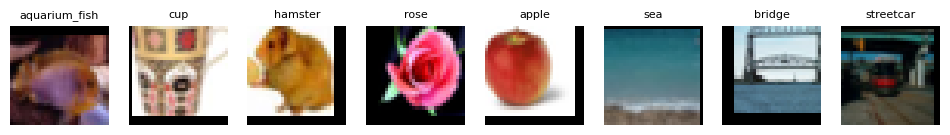

In [24]:
def showImage(image:torch.Tensor, label:torch.Tensor) -> None:
    """看一下一批图片和标签"""
    images, labels = image[:8].cpu(), label[:8].cpu()

    # view函数将mean和std调整为与图像张量相同的形状，以便进行逐元素操作
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1)
    images = images * std + mean

    plt.figure(figsize=(12, 6))
    for index, image in enumerate(images):
        # subplot函数创建一个1行8列的子图，并在每个子图中显示对应的图像和标签
        plt.subplot(1, 8, index + 1)
        # permute函数将图像张量的维度从(C, H, W)调整为(H, W, C)，clamp函数将像素值限制在0到1之间，以便正确显示图像
        plt.imshow(image.permute(1, 2, 0).clamp(0,1))
        plt.title(class_names[labels[index]], fontsize=8)
        plt.axis("off")
    plt.show()

images, labels = next(iter(trainLoader))
images.shape, labels.shape
showImage(images, labels)

## 构建模型
- 改 conv1 和 maxpool：为了适配 CIFAR100 的小图，避免过早下采样。
- 改 fc：为了把 ImageNet 的 1000 类输出改成 CIFAR100 的 100 类输出。
- fc.in_features 对 ResNet18 是 512，但最好不要写死。


In [25]:
from models import resnet18, buildDenseNet

In [ ]:
model = resnet18(num_classes=num_classes).to(device)
model

In [ ]:
model = buildDenseNet(num_classes=num_classes).to(device)
model

## 损失函数、优化器、调度器
- 损失函数: 交叉熵
- 优化器: AdamW
- 调度器: CosineAnnealingLR

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

## 训练一个epoch

In [ ]:
def trainOneEpoch(model: nn.Module, dataloader: DataLoader, criterion: nn.Module, optimizer: torch.optim.Optimizer, epoch: int) -> tuple:
    """训练一个epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc=f"[Train] Epoch {epoch}: ", leave=False, ascii=False)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({"loss": f"{running_loss / total:.4f}", "acc": f"{correct / total * 100:.2f}%"})

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
@torch.no_grad()
def evaluate(model: nn.Module, dataloader: DataLoader, criterion: nn.Module, epoch: int, task: Literal["Val", "Test"]) -> tuple:
    """评估模型性能"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc=f"[{task}] Epoch {epoch}: ", leave=False, ascii=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(dim=1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({"loss": f"{running_loss / total:.4f}", "acc": f"{correct / total * 100:.2f}%"})

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
# Cell 9: 正式训练

bestAccuracy = 0.0
history = {
    "trainLoss": [],
    "trainAccuracy": [],
    "testLoss": [],
    "testAccuracy": [],
}

for epoch in range(1, epochs + 1):
    trainLoss, trainAccuracy = trainOneEpoch(model, trainLoader, criterion, optimizer, epoch)
    testLoss, testAccuracy = evaluate(model, testLoader, criterion, epoch, "Val")

    scheduler.step()

    history["trainLoss"].append(trainLoss)
    history["trainAccuracy"].append(trainAccuracy)
    history["testLoss"].append(testLoss)
    history["testAccuracy"].append(testAccuracy)

    print(
        f"Epoch {epoch:03d} | "
        f"train loss {trainLoss:.4f} | "
        f"train acc {trainAccuracy:.4f} | "
        f"test loss {testLoss:.4f} | "
        f"test acc {testAccuracy:.4f}"
    )

    if testAccuracy > bestAccuracy:
        bestAccuracy = testAccuracy
        checkpointPath = CHECKPOINTS_DIR / "resnet18Cifar10Best.pth"
        torch.save(model.state_dict(), checkpointPath)


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


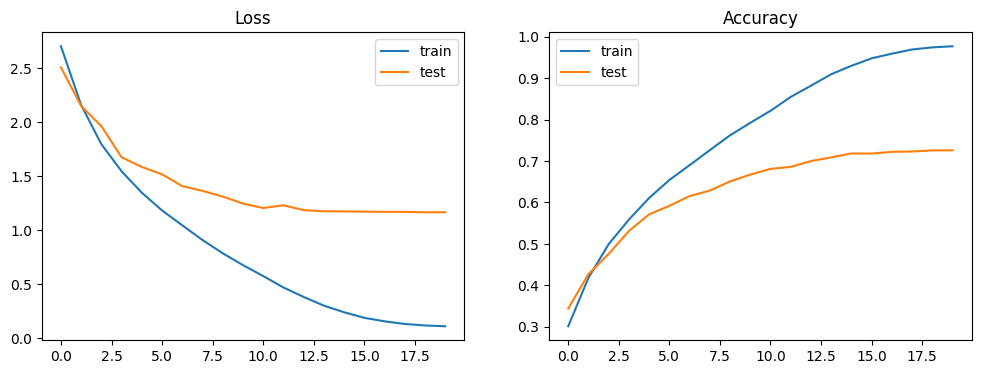

In [ ]:
# Cell 10: 绘制训练曲线

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["trainLoss"], label="train")
plt.plot(history["testLoss"], label="test")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["trainAccuracy"], label="train")
plt.plot(history["testAccuracy"], label="test")
plt.title("Accuracy")
plt.legend()

plt.show()


In [ ]:
best_model = buildDenseNet(num_classes=num_classes).to(device)

best_model.load_state_dict(torch.load(CHECKPOINTS_DIR / "resnet18Cifar10Best.pth"))
best_model.eval()

images, labels = next(iter(testLoader))

with torch.no_grad():
    outputs = best_model(images.to(device))
    _, predicted = outputs.max(dim=1)

showImage(images, labels)
showImage(images, predicted)

NameError: name 'buildResNet18' is not defined